In [24]:
import numpy as np # pandas/numpy: data loading & manipulation
import pandas as pd
import matplotlib.pyplot as plt # matplotlib/seaborn: plotting
import seaborn as sns

from sklearn.model_selection import train_test_split # sklearn: train/test split, scaling, logistic regression w/ L1 (lasso), metrics
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

sns.set_style("whitegrid")

In [25]:
df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv") # load data

print(df.head())

# list of variables that are logically binary/categorical
binary_vars = [
    "Diabetes_binary", "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
    "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
    "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "DiffWalk", "Sex",
]


# convert those columns to pandas 'category' dtype
for col in binary_vars: 
    df[col] = df[col].astype("category")

   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0   

In [26]:
# Clean up code

# check missing values per column
print(df.isna().sum())

# remove rows with any missing values
df = df.dropna()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [27]:
# Scale numeric columns
# identify numeric (non-categorical) columns and standardize them (z-score),
numeric_cols = df.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# summary statistics
print(df.describe(include="all"))

# ensure the target is categorical
df["Diabetes_binary"] = df["Diabetes_binary"].astype("category")

# frequency table + proportions for HighBP
print(df["HighBP"].value_counts())
print(df["HighBP"].value_counts(normalize=True))

        Diabetes_binary    HighBP  HighChol  CholCheck           BMI  \
count          253680.0  253680.0  253680.0   253680.0  2.536800e+05   
unique              2.0       2.0       2.0        2.0           NaN   
top                 0.0       0.0       0.0        1.0           NaN   
freq           218334.0  144851.0  146089.0   244210.0           NaN   
mean                NaN       NaN       NaN        NaN -2.482754e-16   
std                 NaN       NaN       NaN        NaN  1.000002e+00   
min                 NaN       NaN       NaN        NaN -2.478916e+00   
25%                 NaN       NaN       NaN        NaN -6.631223e-01   
50%                 NaN       NaN       NaN        NaN -2.091739e-01   
75%                 NaN       NaN       NaN        NaN  3.960906e-01   
max                 NaN       NaN       NaN        NaN  1.053427e+01   

          Smoker    Stroke  HeartDiseaseorAttack  PhysActivity    Fruits  ...  \
count   253680.0  253680.0              253680.0      

### EDA

Checks class imbalance (amount of diabetes vs non-diabete individuals)

Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64
Diabetes_binary
0.0    86.066698
1.0    13.933302
Name: proportion, dtype: float64


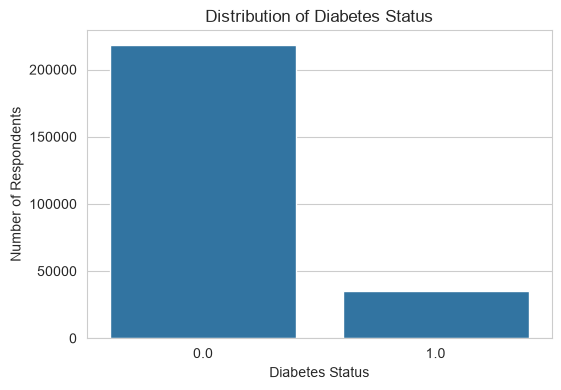

In [28]:
diabetes_counts = df["Diabetes_binary"].value_counts()
diabetes_percent = df["Diabetes_binary"].value_counts(normalize=True) * 100

print(diabetes_counts)
print(diabetes_percent)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Diabetes_binary")
plt.title("Distribution of Diabetes Status")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of Respondents")
plt.show()

### Diabetes prevalence by age group

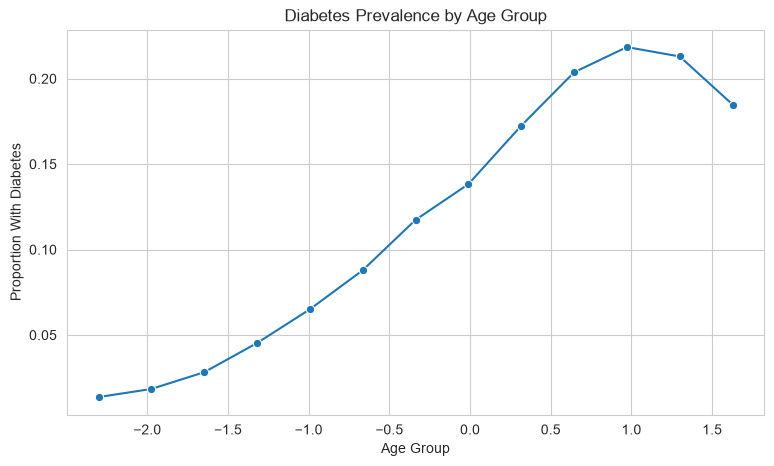

In [29]:
age_diabetes = (
    df.groupby("Age", observed=False)["Diabetes_binary"]
    .apply(lambda x: x.astype(int).mean())
    .reset_index(name="Diabetes_Rate")
)

plt.figure(figsize=(9, 5))
sns.lineplot(data=age_diabetes, x="Age", y="Diabetes_Rate", marker="o")
plt.title("Diabetes Prevalence by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Proportion With Diabetes")
plt.show()

### BMI distribution by diabetes status

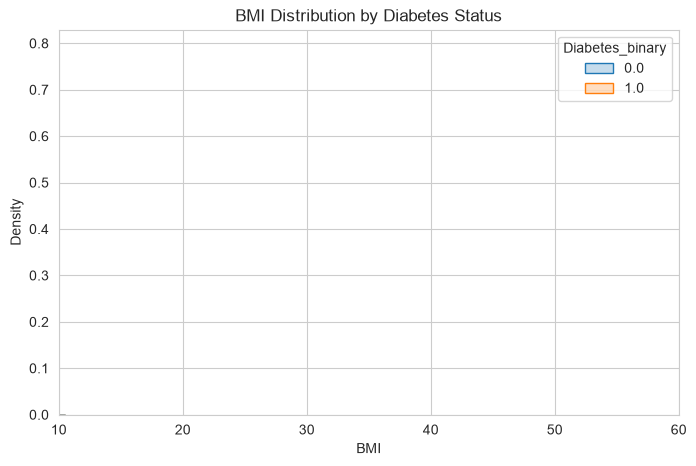

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="BMI",
    hue="Diabetes_binary",
    bins=40,
    stat="density",
    common_norm=False,
    element="step"
)
plt.xlim(10, 60)
plt.title("BMI Distribution by Diabetes Status")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.show()

diabetes prevalence across bmi categories

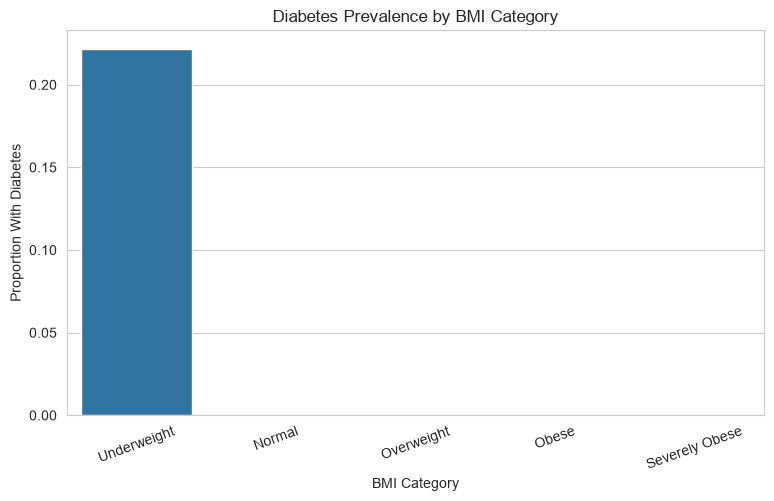

In [31]:
df = df.copy()

df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 25, 30, 40, np.inf],
    labels=["Underweight", "Normal", "Overweight", "Obese", "Severely Obese"]
)

bmi_rates = (
    df.groupby("BMI_Category", observed=False)["Diabetes_binary"]
    .apply(lambda x: x.astype(int).mean())
    .reset_index(name="Diabetes_Rate")
)

plt.figure(figsize=(9, 5))
sns.barplot(data=bmi_rates, x="BMI_Category", y="Diabetes_Rate")
plt.title("Diabetes Prevalence by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Proportion With Diabetes")
plt.xticks(rotation=20)
plt.show()

Combined effects of high blood pressure and high cholesterol

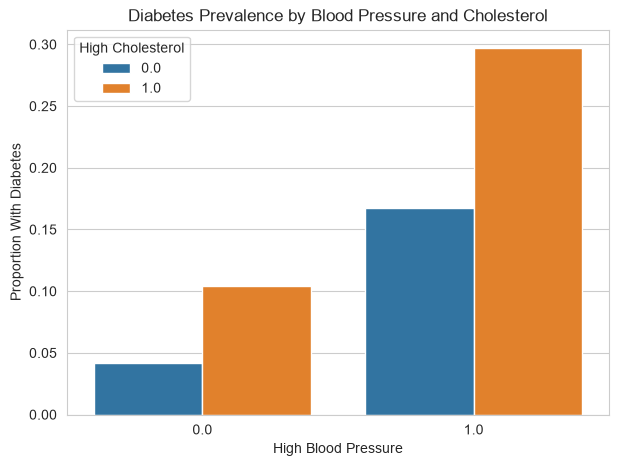

In [32]:
combined_risk = (
    df.groupby(["HighBP", "HighChol"], observed=False)["Diabetes_binary"]
    .apply(lambda x: x.astype(int).mean())
    .reset_index(name="Diabetes_Rate")
)

plt.figure(figsize=(7, 5))
sns.barplot(
    data=combined_risk,
    x="HighBP",
    y="Diabetes_Rate",
    hue="HighChol"
)
plt.title("Diabetes Prevalence by Blood Pressure and Cholesterol")
plt.xlabel("High Blood Pressure")
plt.ylabel("Proportion With Diabetes")
plt.legend(title="High Cholesterol")
plt.show()

Diabetes frequency by general health

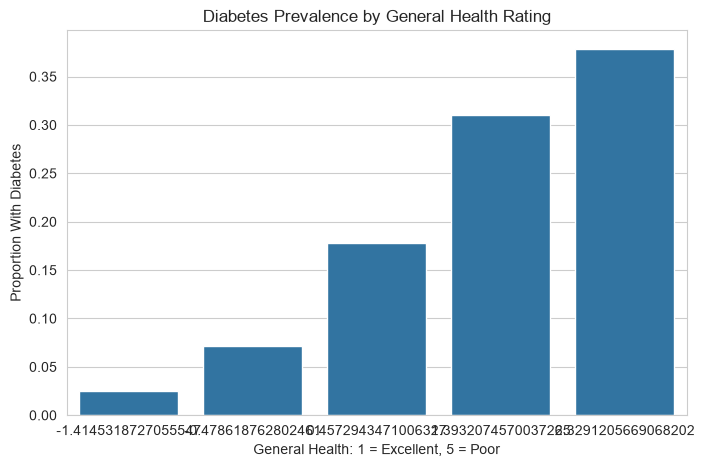

In [33]:
genhealth_rates = (
    df.groupby("GenHlth", observed=False)["Diabetes_binary"]
    .apply(lambda x: x.astype(int).mean())
    .reset_index(name="Diabetes_Rate")
)

plt.figure(figsize=(8, 5))
sns.barplot(data=genhealth_rates, x="GenHlth", y="Diabetes_Rate")
plt.title("Diabetes Prevalence by General Health Rating")
plt.xlabel("General Health: 1 = Excellent, 5 = Poor")
plt.ylabel("Proportion With Diabetes")
plt.show()

Correlation Heatmap

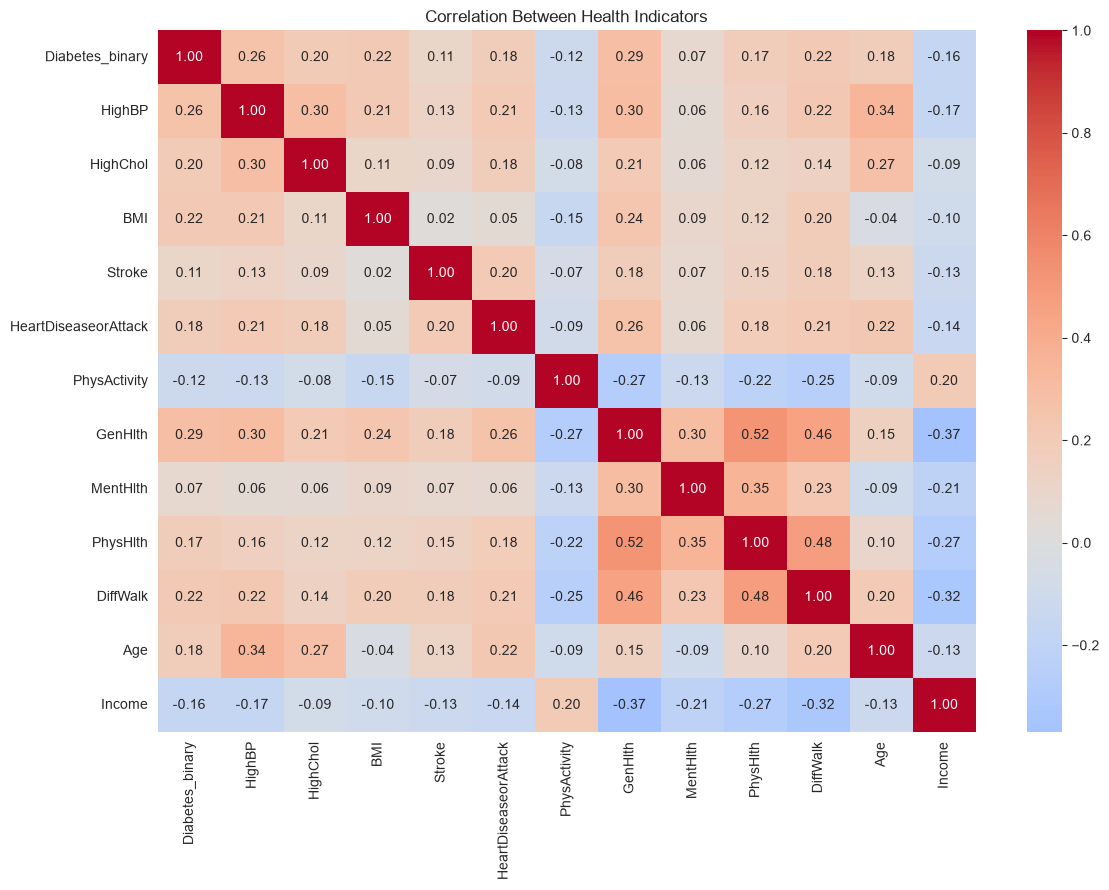

In [34]:
correlation_columns = [
    "Diabetes_binary", "HighBP", "HighChol", "BMI", "Stroke",
    "HeartDiseaseorAttack", "PhysActivity", "GenHlth",
    "MentHlth", "PhysHlth", "DiffWalk", "Age", "Income"
]

corr_data = df[correlation_columns].astype(float)
corr_matrix = corr_data.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Between Health Indicators")
plt.tight_layout()
plt.show()